\
# KBO 팀 득점 추정 모델
## 공격 이벤트 분해와 연도별 교차검증

이 프로젝트는 2020–2024년 KBO 팀 시즌 타격 기록을 이용해 **팀 득점과 공격 이벤트의 선형 관계**를 분석합니다.

기존 모형의 `안타(H) + 홈런(HR)` 조합은 홈런이 안타에 포함된다는 구조적 중복이 있습니다. 이를 개선하기 위해 안타를 1루타·2루타·3루타·홈런으로 분해하고, 연도별 교차검증으로 새로운 시즌에서의 오차를 평가했습니다.

> 분석 목표는 미래 득점을 확정적으로 예언하거나 변수의 인과효과를 증명하는 것이 아닙니다. 제한된 팀-시즌 관측자료에서 재현 가능한 추정·검증 절차를 구축하는 데 초점을 둡니다.


## 1. 실행 환경과 경로 설정

In [1]:
\
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

BASE_DIR = Path.cwd()
DATA_CANDIDATES = [BASE_DIR / "team_records.xlsx", BASE_DIR / "팀기록.xlsx"]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("team_records.xlsx 또는 팀기록.xlsx를 프로젝트 폴더에 넣어주세요.")

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Data path: /mnt/data/KBO_regression_revised/team_records.xlsx
Output directory: /mnt/data/KBO_regression_revised/outputs


## 2. 데이터 불러오기와 정제

원본 파일에는 타격·투구·수비 지표가 함께 들어 있습니다. 이번 분석에서는 첫 번째 타격 구간만 선택하고 다음을 수행합니다.

- 팀명 앞의 공백 문자 제거
- `SK`와 `SSG` 표기 통일
- 안타를 1루타·2루타·3루타·홈런으로 분해
- 볼넷과 몸에 맞는 공을 `BB_HBP`로 결합
- 팀·연도 중복, 결측값, 경기 수, 파생변수 범위 검증


In [2]:
\
raw = pd.read_excel(DATA_PATH)

# 원본의 첫 31개 열은 팀 타격 기록 구간입니다.
batting = raw.iloc[:, :31].copy()
batting.columns = [
    "Rank", "Team", "Year", "G", "oWAR", "dWAR", "PA", "ePA", "AB", "R",
    "H", "2B", "3B", "HR", "TB", "RBI", "SB", "CS", "BB", "HP", "IB",
    "SO", "GDP", "SH", "SF", "AVG", "OBP", "SLG", "OPS", "ISO", "wRC_plus"
]

batting["Team"] = (
    batting["Team"]
    .astype(str)
    .str.replace("\\u00a0", "", regex=False)
    .str.strip()
    .replace({"SK": "SSG"})
)

integer_columns = [
    "Year", "G", "PA", "ePA", "AB", "R", "H", "2B", "3B", "HR", "TB",
    "RBI", "SB", "CS", "BB", "HP", "IB", "SO", "GDP", "SH", "SF"
]
batting[integer_columns] = batting[integer_columns].apply(pd.to_numeric, errors="raise").astype(int)

batting["1B"] = batting["H"] - batting["2B"] - batting["3B"] - batting["HR"]
batting["BB_HBP"] = batting["BB"] + batting["HP"]

analysis_columns = [
    "Team", "Year", "G", "PA", "R", "H", "1B", "2B", "3B", "HR",
    "BB", "HP", "BB_HBP", "SB", "CS", "SO"
]
model_data = batting[analysis_columns].sort_values(["Year", "Team"]).reset_index(drop=True)

quality_checks = pd.Series({
    "original_rows": len(raw),
    "original_columns": raw.shape[1],
    "analysis_rows": len(model_data),
    "unique_team_years": model_data[["Team", "Year"]].drop_duplicates().shape[0],
    "missing_values": int(model_data.isna().sum().sum()),
    "duplicate_team_years": int(model_data.duplicated(["Team", "Year"]).sum()),
    "negative_singles": int((model_data["1B"] < 0).sum()),
    "years": model_data["Year"].nunique(),
    "teams_per_year_min": int(model_data.groupby("Year")["Team"].nunique().min()),
    "teams_per_year_max": int(model_data.groupby("Year")["Team"].nunique().max()),
    "unique_game_counts": int(model_data["G"].nunique()),
})

assert len(model_data) == 50
assert model_data[["Team", "Year"]].drop_duplicates().shape[0] == 50
assert model_data.isna().sum().sum() == 0
assert model_data.duplicated(["Team", "Year"]).sum() == 0
assert (model_data["1B"] >= 0).all()
assert model_data.groupby("Year")["Team"].nunique().eq(10).all()
assert model_data["G"].eq(144).all()

model_data.to_csv(OUTPUT_DIR / "kbo_team_batting_processed.csv", index=False, encoding="utf-8-sig")

print("Data quality checks")
display(quality_checks.to_frame("value"))
print("\nProcessed data preview")
display(model_data.head())


Data quality checks


,value
original_rows,50
original_columns,88
analysis_rows,50
unique_team_years,50
missing_values,0
duplicate_team_years,0
negative_singles,0
years,5
teams_per_year_min,10
teams_per_year_max,10



Processed data preview


,Team,Year,G,PA,R,H,1B,2B,3B,HR,BB,HP,BB_HBP,SB,CS,SO
0,KIA,2020,144,5642,724,1355,988,224,13,130,535,69,604,47,25,957
1,KT,2020,144,5762,813,1432,1010,238,21,163,554,52,606,106,50,1097
2,LG,2020,144,5681,802,1384,953,253,29,149,509,75,584,83,39,969
3,NC,2020,144,5833,888,1483,1010,258,28,187,529,104,633,101,38,997
4,SSG,2020,144,5502,634,1212,875,177,17,143,511,69,580,81,45,981


## 3. 데이터 구성 확인

In [3]:
\
yearly_summary = (
    model_data.groupby("Year")
    .agg(
        teams=("Team", "nunique"),
        mean_runs=("R", "mean"),
        min_runs=("R", "min"),
        max_runs=("R", "max"),
    )
    .reset_index()
)

descriptive_summary = model_data[["R", "H", "HR", "BB", "SB", "SO"]].describe().T

print("Yearly summary")
display(yearly_summary)
print("\nSelected variable summary")
display(descriptive_summary)


Yearly summary


,Year,teams,mean_runs,min_runs,max_runs
0,2020,10,743.600,551,888
1,2021,10,689.600,568,755
2,2022,10,652.300,564,720
3,2023,10,662.200,604,767
4,2024,10,774.000,672,858



Selected variable summary


,count,mean,std,min,25%,50%,75%,max
R,50.000,704.340,78.519,551.000,640.000,717.000,758.250,888.000
H,50.000,"1,316.240",85.811,"1,111.000","1,255.500","1,320.500","1,365.750","1,542.000"
HR,50.000,119.360,31.252,61.000,100.000,114.000,136.750,187.000
BB,50.000,530.800,50.254,417.000,500.250,525.500,558.500,645.000
SB,50.000,98.300,29.207,47.000,81.500,99.000,110.500,184.000
SO,50.000,"1,026.320",103.427,796.000,960.000,"1,006.000","1,089.500","1,286.000"


\
## 4. 모형 설계

세 가지 모형을 비교합니다.

1. **평균 기준선**: 학습 연도의 평균 득점을 예측값으로 사용
2. **기존 5변수 OLS**: `H + HR + BB + SB + SO`
3. **이벤트 분해 OLS**: `1B + 2B + 3B + HR + BB_HBP + SB + SO`

평가는 `LeaveOneGroupOut`을 사용해 **한 연도를 통째로 검증 세트로 제외**합니다. 따라서 같은 연도의 팀 기록이 학습·검증 세트에 동시에 섞이지 않습니다.

- 전체 5개 폴드는 ‘보지 못한 연도’에 대한 안정성을 확인합니다.
- 2024년 폴드는 2020–2023년으로 학습하고 2024년을 평가하므로 시간 순서를 지킨 별도 확인값으로 해석할 수 있습니다.


In [4]:
\
TARGET = "R"
GROUP = "Year"

MODEL_SPECS = {
    "Mean baseline": None,
    "Original 5-feature OLS": ["H", "HR", "BB", "SB", "SO"],
    "Event-decomposed OLS": ["1B", "2B", "3B", "HR", "BB_HBP", "SB", "SO"],
}

logo = LeaveOneGroupOut()
y = model_data[TARGET].to_numpy(dtype=float)
groups = model_data[GROUP].to_numpy()

prediction_frames = []
metric_rows = []
year_metric_rows = []

for model_name, features in MODEL_SPECS.items():
    out_of_fold = np.full(len(model_data), np.nan, dtype=float)

    # Leave one year out at a time
    split_source = np.zeros((len(model_data), 1)) if features is None else model_data[features]
    for train_idx, test_idx in logo.split(split_source, y, groups):
        if features is None:
            fold_prediction = np.repeat(y[train_idx].mean(), len(test_idx))
        else:
            estimator = LinearRegression()
            estimator.fit(model_data.loc[train_idx, features], y[train_idx])
            fold_prediction = estimator.predict(model_data.loc[test_idx, features])

        out_of_fold[test_idx] = fold_prediction

        fold_year = int(groups[test_idx][0])
        year_metric_rows.append({
            "Model": model_name,
            "Year": fold_year,
            "MAE": mean_absolute_error(y[test_idx], fold_prediction),
            "RMSE": mean_squared_error(y[test_idx], fold_prediction) ** 0.5,
            "R2": r2_score(y[test_idx], fold_prediction),
        })

    metric_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y, out_of_fold),
        "RMSE": mean_squared_error(y, out_of_fold) ** 0.5,
        "R2": r2_score(y, out_of_fold),
    })

    frame = model_data[["Team", "Year", "R"]].copy()
    frame["Model"] = model_name
    frame["Predicted_R"] = out_of_fold
    frame["Residual"] = frame["R"] - frame["Predicted_R"]
    frame["Absolute_Error"] = frame["Residual"].abs()
    prediction_frames.append(frame)

model_comparison = pd.DataFrame(metric_rows).sort_values("MAE").reset_index(drop=True)
year_metrics = pd.DataFrame(year_metric_rows).sort_values(["Model", "Year"]).reset_index(drop=True)
cv_predictions = pd.concat(prediction_frames, ignore_index=True)

model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
year_metrics.to_csv(OUTPUT_DIR / "validation_metrics_by_year.csv", index=False, encoding="utf-8-sig")
cv_predictions.to_csv(OUTPUT_DIR / "cross_validated_predictions.csv", index=False, encoding="utf-8-sig")

print("Leave-one-year-out model comparison")
display(model_comparison)

print("2024 chronological holdout check")
display(year_metrics[year_metrics["Year"].eq(2024)].sort_values("MAE"))


Leave-one-year-out model comparison


,Model,MAE,RMSE,R2
0,Event-decomposed OLS,15.650,18.851,0.941
1,Original 5-feature OLS,16.522,21.246,0.925
2,Mean baseline,70.955,85.382,-0.207


2024 chronological holdout check


,Model,Year,MAE,RMSE,R2
4,Event-decomposed OLS,2024,13.113,16.893,0.863
14,Original 5-feature OLS,2024,15.783,19.110,0.825
9,Mean baseline,2024,90.060,98.324,-3.635


## 5. 교차검증 결과 시각화

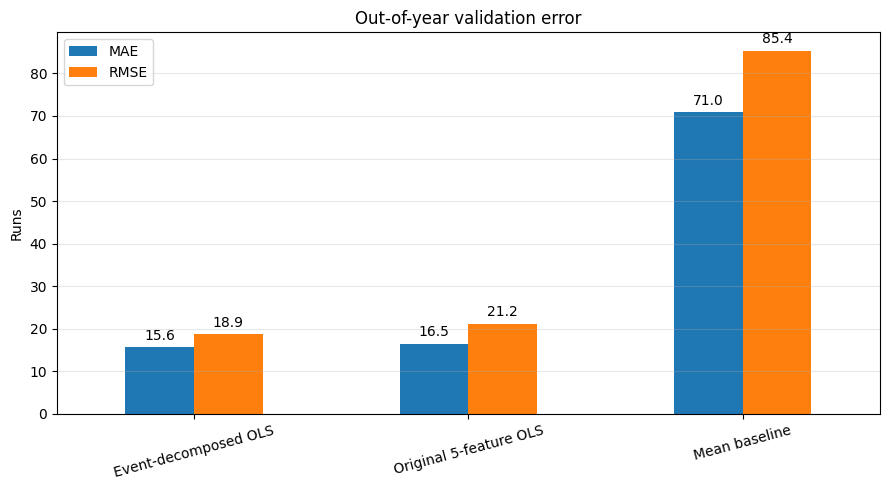

In [5]:
\
ax = (
    model_comparison.set_index("Model")[["MAE", "RMSE"]]
    .plot(kind="bar", figsize=(9, 5), rot=15)
)
ax.set_title("Out-of-year validation error")
ax.set_xlabel("")
ax.set_ylabel("Runs")
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


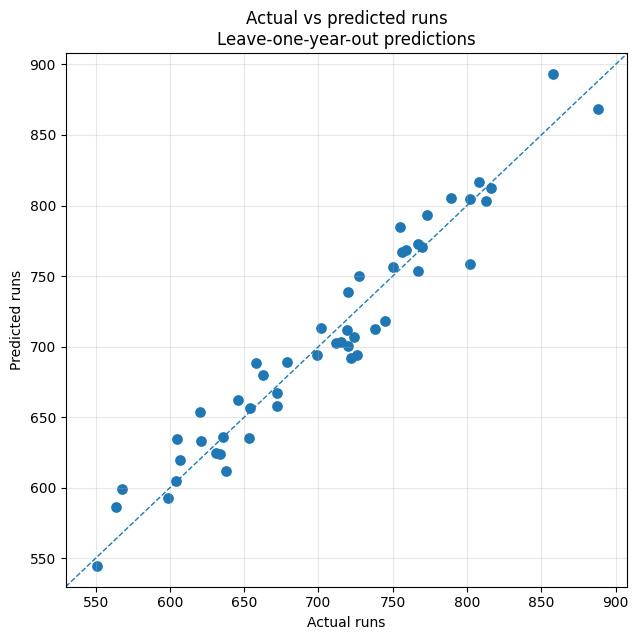

In [6]:
\
FINAL_MODEL_NAME = "Event-decomposed OLS"
final_cv = cv_predictions[cv_predictions["Model"].eq(FINAL_MODEL_NAME)].copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(final_cv["R"], final_cv["Predicted_R"], s=45)
low = min(final_cv["R"].min(), final_cv["Predicted_R"].min()) - 15
high = max(final_cv["R"].max(), final_cv["Predicted_R"].max()) + 15
ax.plot([low, high], [low, high], linestyle="--", linewidth=1)
ax.set_xlim(low, high)
ax.set_ylim(low, high)
ax.set_title("Actual vs predicted runs\nLeave-one-year-out predictions")
ax.set_xlabel("Actual runs")
ax.set_ylabel("Predicted runs")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()


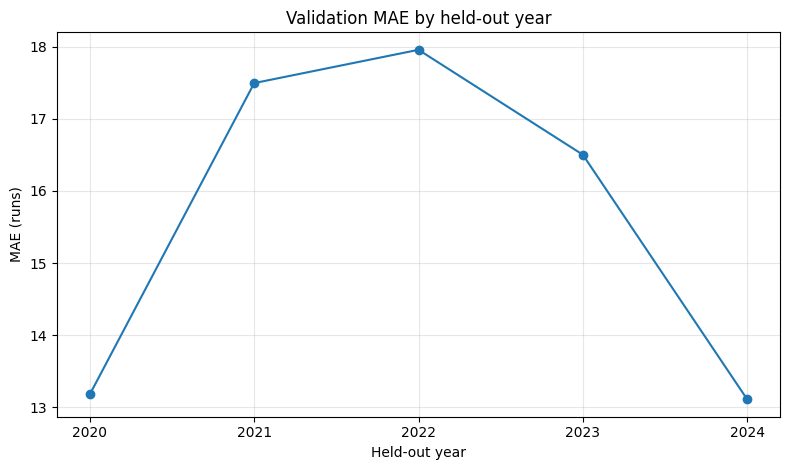

In [7]:
\
final_year_metrics = year_metrics[year_metrics["Model"].eq(FINAL_MODEL_NAME)].copy()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(final_year_metrics["Year"], final_year_metrics["MAE"], marker="o")
ax.set_title("Validation MAE by held-out year")
ax.set_xlabel("Held-out year")
ax.set_ylabel("MAE (runs)")
ax.set_xticks(final_year_metrics["Year"])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_by_year.png", dpi=180, bbox_inches="tight")
plt.show()


\
## 6. 최종 OLS 모형과 진단

교차검증에서 선택된 이벤트 분해 모형을 전체 50개 관측치에 적합해 계수와 진단값을 확인합니다.

- 계수의 불확실성은 **HC3 강건 표준오차**로 계산합니다.
- 다중공선성은 VIF로 점검합니다.
- 이분산성은 Breusch–Pagan 검정, 잔차 정규성은 Jarque–Bera 검정으로 확인합니다.
- Cook's distance가 `4 / n`보다 큰 관측치는 민감도 점검 후보로 표시합니다.

전체 표본 적합도의 $R^2$는 설명용이며, 성능 평가는 앞의 교차검증 지표를 우선합니다.


In [8]:
\
FINAL_FEATURES = MODEL_SPECS[FINAL_MODEL_NAME]
X = model_data[FINAL_FEATURES].astype(float)
X_with_const = sm.add_constant(X)

ols_model = sm.OLS(y, X_with_const).fit()
robust_model = ols_model.get_robustcov_results(cov_type="HC3")

conf_int = robust_model.conf_int(alpha=0.05)
coefficient_table = pd.DataFrame({
    "Feature": ["Intercept"] + FINAL_FEATURES,
    "Coefficient": robust_model.params,
    "Robust_SE_HC3": robust_model.bse,
    "CI_2.5%": conf_int[:, 0],
    "CI_97.5%": conf_int[:, 1],
    "p_value": robust_model.pvalues,
})

vif_table = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "VIF": [variance_inflation_factor(X_with_const.to_numpy(), i) for i in range(1, X_with_const.shape[1])],
})

bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(ols_model.resid, ols_model.model.exog)
jb_result = stats.jarque_bera(ols_model.resid)

X_standardized = (X - X.mean()) / X.std(ddof=0)
standardized_condition_number = np.linalg.cond(sm.add_constant(X_standardized).to_numpy())

influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
cooks_threshold = 4 / len(model_data)
influence_table = model_data[["Team", "Year", "R"]].copy()
influence_table["Fitted_R"] = ols_model.fittedvalues
influence_table["Residual"] = ols_model.resid
influence_table["Cooks_D"] = cooks_d
influence_table["Above_4_over_n"] = influence_table["Cooks_D"] > cooks_threshold
influence_table = influence_table.sort_values("Cooks_D", ascending=False).reset_index(drop=True)

# 영향력이 상대적으로 큰 관측치를 제외한 계수 방향 민감도 점검
sensitivity_mask = cooks_d <= cooks_threshold
sensitivity_model = sm.OLS(
    y[sensitivity_mask],
    sm.add_constant(X.loc[sensitivity_mask])
).fit().get_robustcov_results(cov_type="HC3")

sensitivity_table = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Full_sample_coefficient": robust_model.params[1:],
    "Sensitivity_coefficient": sensitivity_model.params[1:],
})
sensitivity_table["Same_sign"] = (
    np.sign(sensitivity_table["Full_sample_coefficient"])
    == np.sign(sensitivity_table["Sensitivity_coefficient"])
)

diagnostics_summary = pd.DataFrame([{
    "Observations": len(model_data),
    "In_sample_R2": ols_model.rsquared,
    "Adjusted_R2": ols_model.rsquared_adj,
    "Max_VIF": vif_table["VIF"].max(),
    "Standardized_condition_number": standardized_condition_number,
    "Breusch_Pagan_p_value": bp_lm_p,
    "Jarque_Bera_p_value": jb_result.pvalue,
    "Max_Cooks_D": influence_table["Cooks_D"].max(),
    "Cooks_threshold_4_over_n": cooks_threshold,
    "Observations_above_threshold": int(influence_table["Above_4_over_n"].sum()),
    "Coefficient_signs_stable_in_sensitivity_check": bool(sensitivity_table["Same_sign"].all()),
}])

coefficient_table.to_csv(OUTPUT_DIR / "coefficient_table.csv", index=False, encoding="utf-8-sig")
vif_table.to_csv(OUTPUT_DIR / "vif_table.csv", index=False, encoding="utf-8-sig")
influence_table.to_csv(OUTPUT_DIR / "influential_observations.csv", index=False, encoding="utf-8-sig")
sensitivity_table.to_csv(OUTPUT_DIR / "coefficient_sensitivity.csv", index=False, encoding="utf-8-sig")
diagnostics_summary.to_csv(OUTPUT_DIR / "diagnostics_summary.csv", index=False, encoding="utf-8-sig")

print("Coefficient estimates with HC3 robust standard errors")
display(coefficient_table)
print("\nVariance inflation factors")
display(vif_table)
print("\nDiagnostics summary")
display(diagnostics_summary.T.rename(columns={0: "value"}))
print("\nHighest Cook's distance observations")
display(influence_table.head(8))
print("\nCoefficient sensitivity after excluding observations above 4/n")
display(sensitivity_table)


Coefficient estimates with HC3 robust standard errors


,Feature,Coefficient,Robust_SE_HC3,CI_2.5%,CI_97.5%,p_value
0,Intercept,-425.904,93.462,-614.518,-237.290,0.000
1,1B,0.495,0.076,0.342,0.648,0.000
2,2B,1.045,0.164,0.714,1.375,0.000
3,3B,0.761,0.417,-0.081,1.603,0.075
4,HR,1.364,0.093,1.177,1.551,0.000
5,BB_HBP,0.395,0.064,0.267,0.523,0.000
6,SB,0.361,0.086,0.188,0.534,0.000
7,SO,-0.028,0.027,-0.082,0.025,0.293



Variance inflation factors


,Feature,VIF
0,1B,2.109
1,2B,1.600
2,3B,1.211
3,HR,1.183
4,BB_HBP,1.202
5,SB,1.209
6,SO,1.355



Diagnostics summary


,value
Observations,50
In_sample_R2,0.958
Adjusted_R2,0.951
Max_VIF,2.109
Standardized_condition_number,2.662
Breusch_Pagan_p_value,0.354
Jarque_Bera_p_value,0.598
Max_Cooks_D,0.120
Cooks_threshold_4_over_n,0.080
Observations_above_threshold,4



Highest Cook's distance observations


,Team,Year,R,Fitted_R,Residual,Cooks_D,Above_4_over_n
0,KIA,2021,568,594.529,-26.529,0.120,True
1,LG,2020,802,768.401,33.599,0.116,True
2,SSG,2021,755,777.316,-22.316,0.084,True
3,두산,2023,620,647.398,-27.398,0.082,True
4,롯데,2021,727,749.500,-22.500,0.073,False
5,키움,2021,722,696.116,25.884,0.070,False
6,KIA,2024,858,883.932,-25.932,0.067,False
7,롯데,2022,605,628.431,-23.431,0.062,False



Coefficient sensitivity after excluding observations above 4/n


,Feature,Full_sample_coefficient,Sensitivity_coefficient,Same_sign
0,1B,0.495,0.515,True
1,2B,1.045,0.847,True
2,3B,0.761,0.788,True
3,HR,1.364,1.326,True
4,BB_HBP,0.395,0.447,True
5,SB,0.361,0.389,True
6,SO,-0.028,-0.035,True


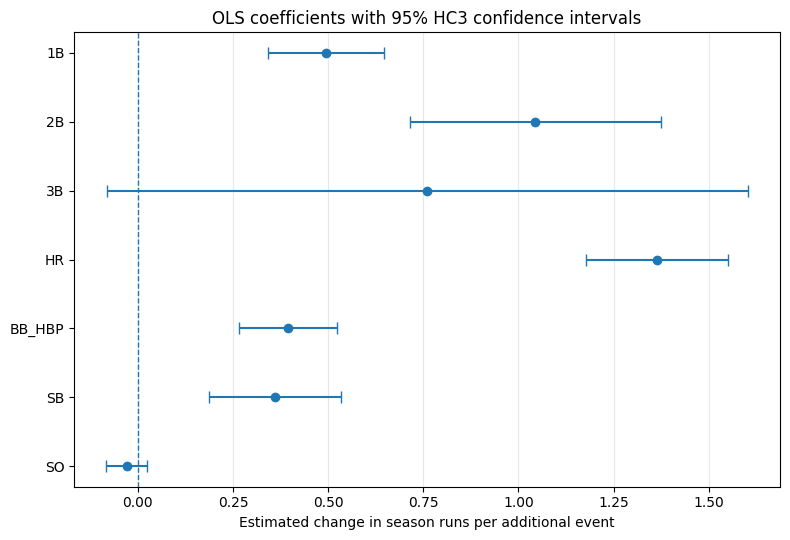

In [9]:
\
plot_coefficients = coefficient_table[coefficient_table["Feature"].ne("Intercept")].copy()
plot_coefficients = plot_coefficients.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(
    plot_coefficients["Coefficient"],
    plot_coefficients["Feature"],
    xerr=[
        plot_coefficients["Coefficient"] - plot_coefficients["CI_2.5%"],
        plot_coefficients["CI_97.5%"] - plot_coefficients["Coefficient"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("OLS coefficients with 95% HC3 confidence intervals")
ax.set_xlabel("Estimated change in season runs per additional event")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "coefficient_intervals.png", dpi=180, bbox_inches="tight")
plt.show()


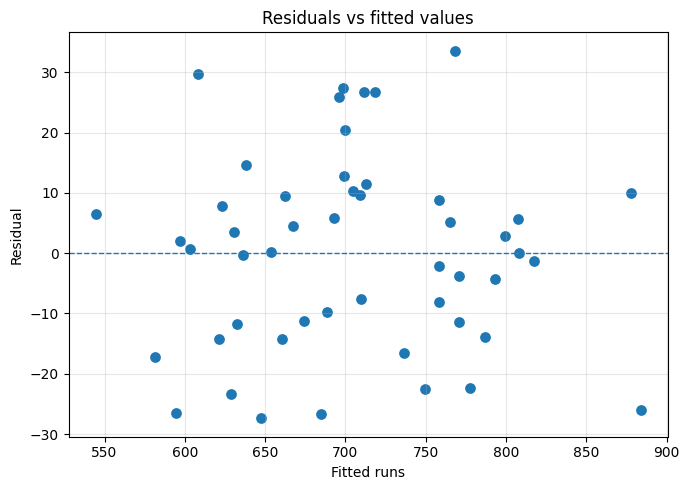

In [10]:
\
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ols_model.fittedvalues, ols_model.resid, s=45)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Residuals vs fitted values")
ax.set_xlabel("Fitted runs")
ax.set_ylabel("Residual")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residuals_vs_fitted.png", dpi=180, bbox_inches="tight")
plt.show()


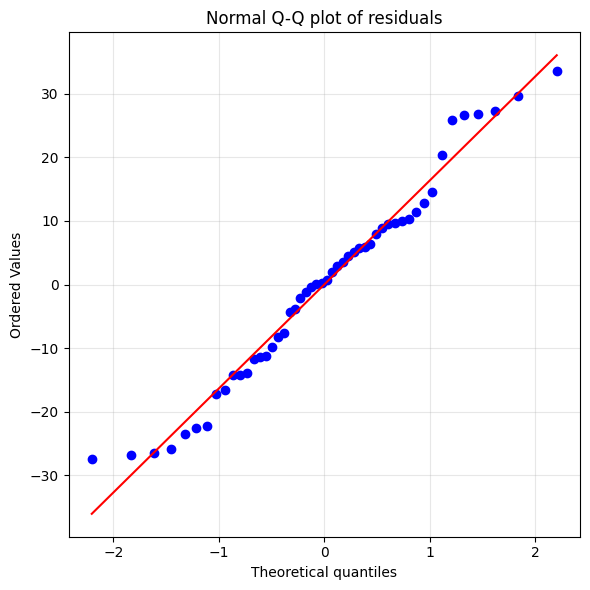

In [11]:
\
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
stats.probplot(ols_model.resid, dist="norm", plot=ax)
ax.set_title("Normal Q-Q plot of residuals")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "qq_plot.png", dpi=180, bbox_inches="tight")
plt.show()


\
## 7. 해석 원칙과 한계

- 계수는 다른 선택 변수를 일정하게 둔 **팀-시즌 수준의 선형 연관성**입니다. 인과효과로 해석하지 않습니다.
- 홈런·2루타 등의 계수를 실제 득점 가치와 동일시할 수 없습니다. 주자 상황, 타순, 구장, 상대 투수, 득점권 성과 등이 생략되어 있습니다.
- 삼진 계수가 유의하지 않더라도 ‘삼진은 득점과 무관하다’고 증명된 것은 아닙니다. 현재 표본과 변수 구성에서 독립적인 선형 연관을 뚜렷하게 확인하지 못했다는 뜻입니다.
- 관측치는 50개뿐이며 같은 구단이 여러 연도에 반복됩니다. 연도별 교차검증은 시즌 단위 누수를 줄이지만, 구단 고정효과와 시간 의존성을 모두 해결하지는 않습니다.
- 2020–2024년은 리그 환경이 달라질 수 있으므로 다른 기간으로 일반화할 때 추가 검증이 필요합니다.


In [12]:
\
best_metrics = model_comparison.loc[model_comparison["Model"].eq(FINAL_MODEL_NAME)].iloc[0]
holdout_2024 = year_metrics[
    year_metrics["Model"].eq(FINAL_MODEL_NAME) & year_metrics["Year"].eq(2024)
].iloc[0]
so_row = coefficient_table[coefficient_table["Feature"].eq("SO")].iloc[0]

print("Final project summary")
print(f"- Observations: {len(model_data)} team-seasons ({model_data['Year'].min()}–{model_data['Year'].max()})")
print(f"- Leave-one-year-out MAE: {best_metrics['MAE']:.2f} runs")
print(f"- Leave-one-year-out RMSE: {best_metrics['RMSE']:.2f} runs")
print(f"- Leave-one-year-out pooled R²: {best_metrics['R2']:.3f}")
print(f"- 2024 holdout MAE: {holdout_2024['MAE']:.2f} runs")
print(f"- 2024 holdout RMSE: {holdout_2024['RMSE']:.2f} runs")
print(f"- 2024 holdout R²: {holdout_2024['R2']:.3f}")
print(f"- Strikeout coefficient HC3 p-value: {so_row['p_value']:.3f}")
print(f"- Maximum VIF: {vif_table['VIF'].max():.2f}")
print("\nAll CSV files and figures were saved under outputs/.")


Final project summary
- Observations: 50 team-seasons (2020–2024)
- Leave-one-year-out MAE: 15.65 runs
- Leave-one-year-out RMSE: 18.85 runs
- Leave-one-year-out pooled R²: 0.941
- 2024 holdout MAE: 13.11 runs
- 2024 holdout RMSE: 16.89 runs
- 2024 holdout R²: 0.863
- Strikeout coefficient HC3 p-value: 0.293
- Maximum VIF: 2.11

All CSV files and figures were saved under outputs/.
